In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from collections import defaultdict
import numpy as np

def plot_csv_columns(file_paths):
    # Dictionary: column_name -> list of (filename, Series)
    column_data = defaultdict(list)

    for file_path in file_paths:
        try:
            df = pd.read_csv(file_path)
        except Exception as e:
            print(f"Failed to read {file_path}: {e}")
            continue
        
        filename = os.path.basename(file_path)
        for column in df.columns:
            if pd.api.types.is_numeric_dtype(df[column]):
                column_data[column].append((filename, df[column].dropna()))
    
    for column, data_list in column_data.items():
        if column == "epoch":
            continue

        plt.figure(figsize=(10, 6))
        plt.title(f"Plot for column: {column}")
        plt.xlabel("Epoch")
        plt.ylabel(column)
        
        # Collect stats for legend
        stats_text = []

        for filename, series in data_list:
            plt.plot(column_data["epoch"][0][1], series.values, label=filename)
            stats = (
                f"{filename}:\n"
                f"Mean={series.mean():.4f}, "
                f"Median={series.median():.4f}, "
                f"Min={series.min():.4f}, "
                f"Max={series.max():.4f}"
            )
            stats_text.append(stats)

        # Add text box with statistics
        plt.legend()
        plt.gcf().text(1.35, 0.5, "\n\n".join(stats_text),
                       fontsize=8, verticalalignment='center',
                       horizontalalignment='right', bbox=dict(facecolor='white', alpha=0.8))

        plt.tight_layout(rect=[0, 0.05, 1, 1])
        plt.grid(True)
        plt.show()

In [2]:
from datetime import datetime

timestamp = 1752873147
dt_object = datetime.fromtimestamp(timestamp)
print(dt_object)

timestamp = 1752879117
dt_object = datetime.fromtimestamp(timestamp)
print(dt_object)

timestamp = 1752861193
dt_object = datetime.fromtimestamp(timestamp)
print(dt_object)

timestamp = 1752867164
dt_object = datetime.fromtimestamp(timestamp)
print(dt_object)

2025-07-18 23:12:27
2025-07-19 00:51:57
2025-07-18 19:53:13
2025-07-18 21:32:44


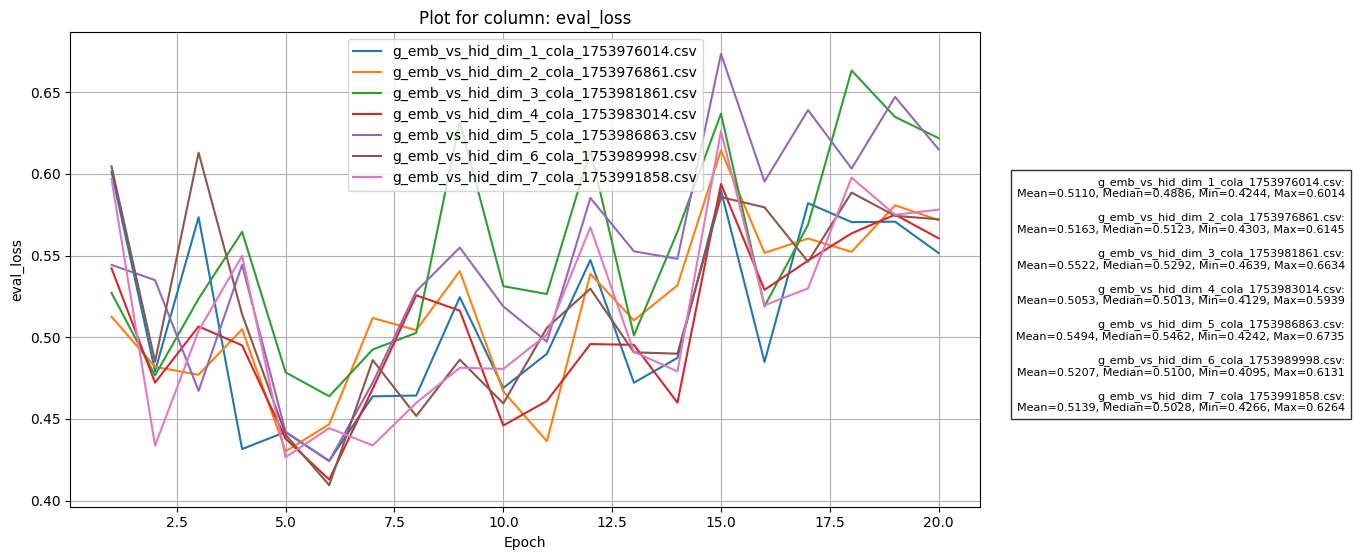

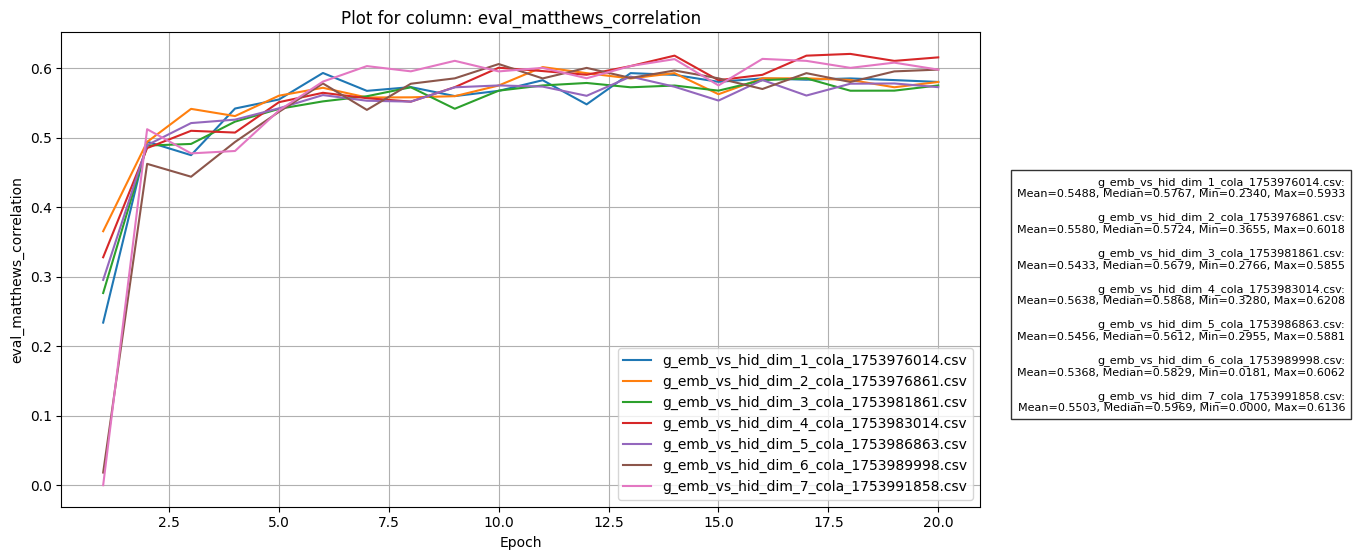

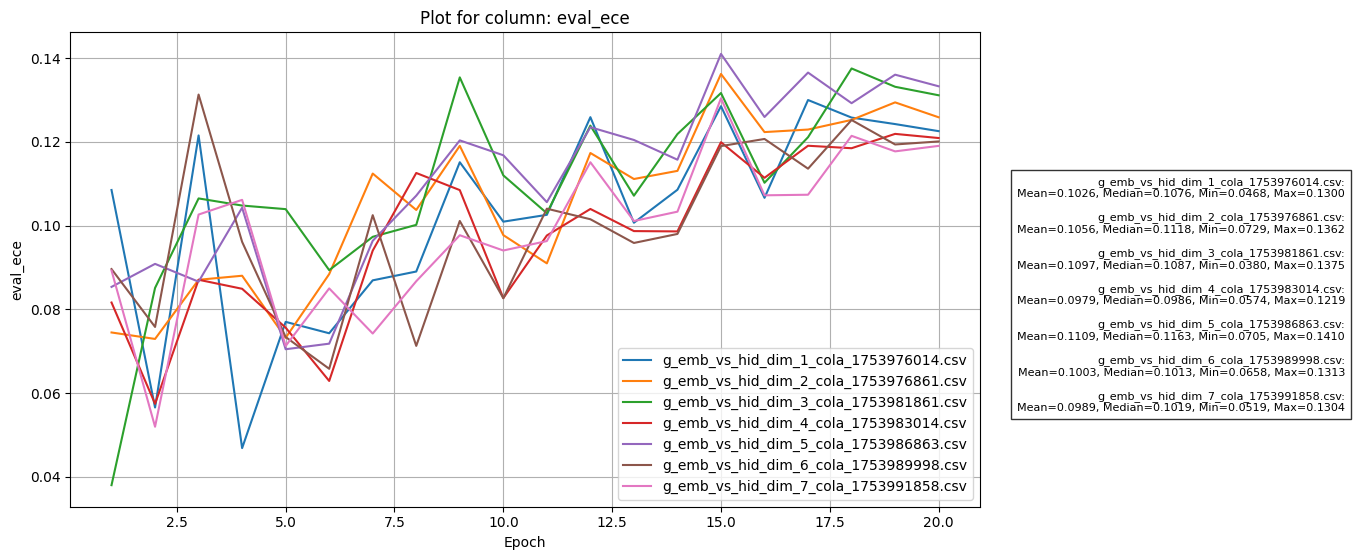

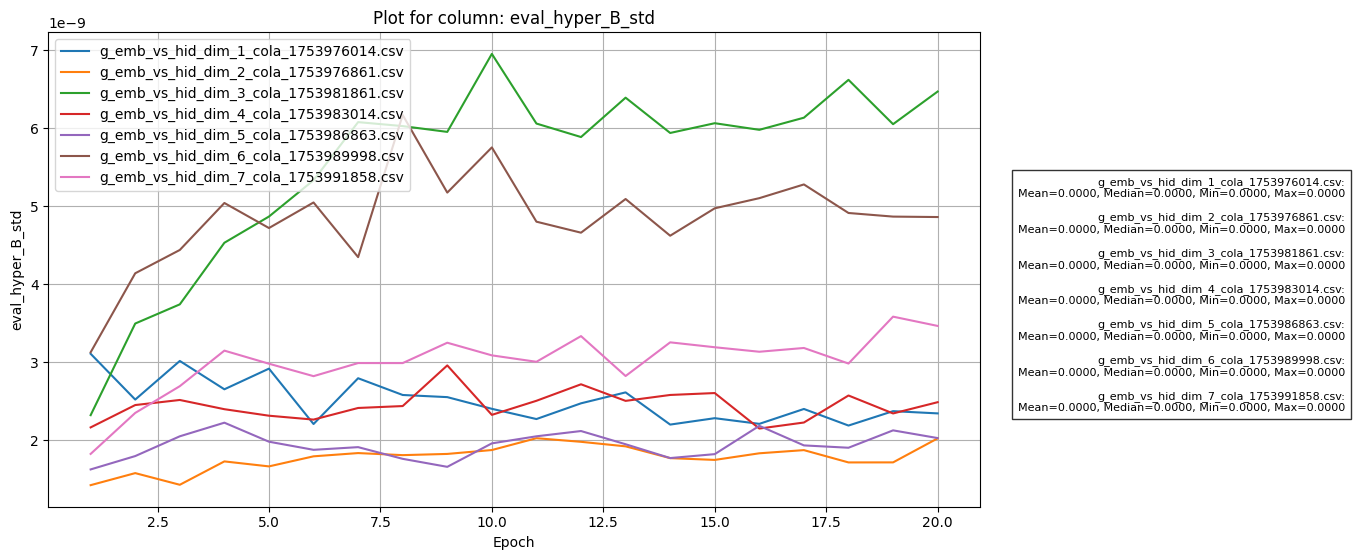

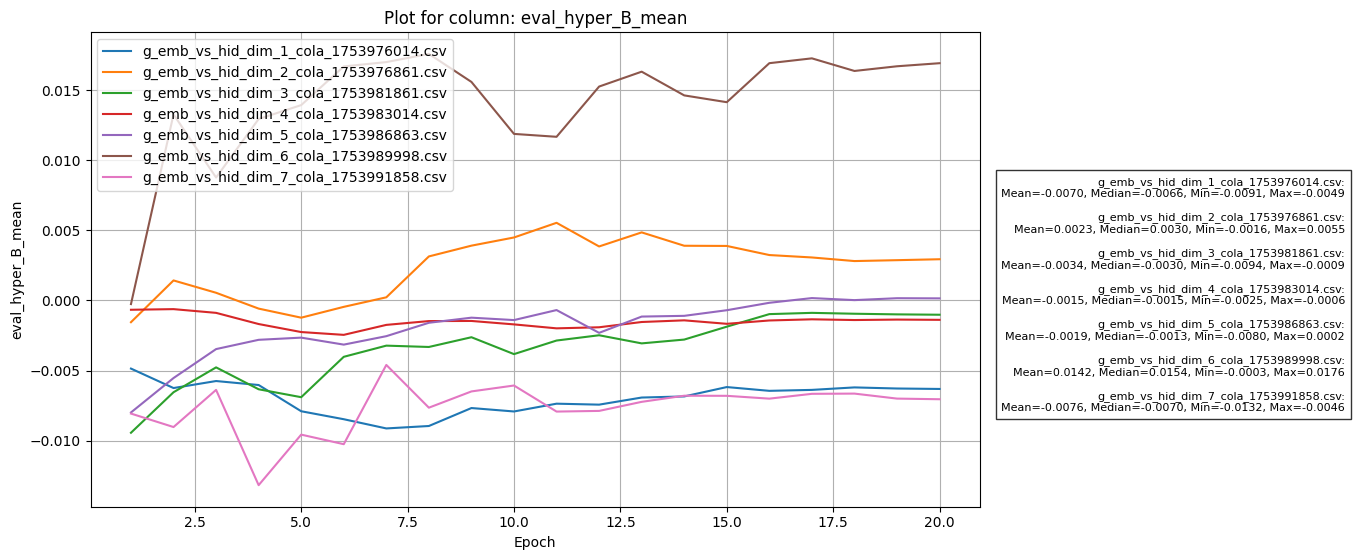

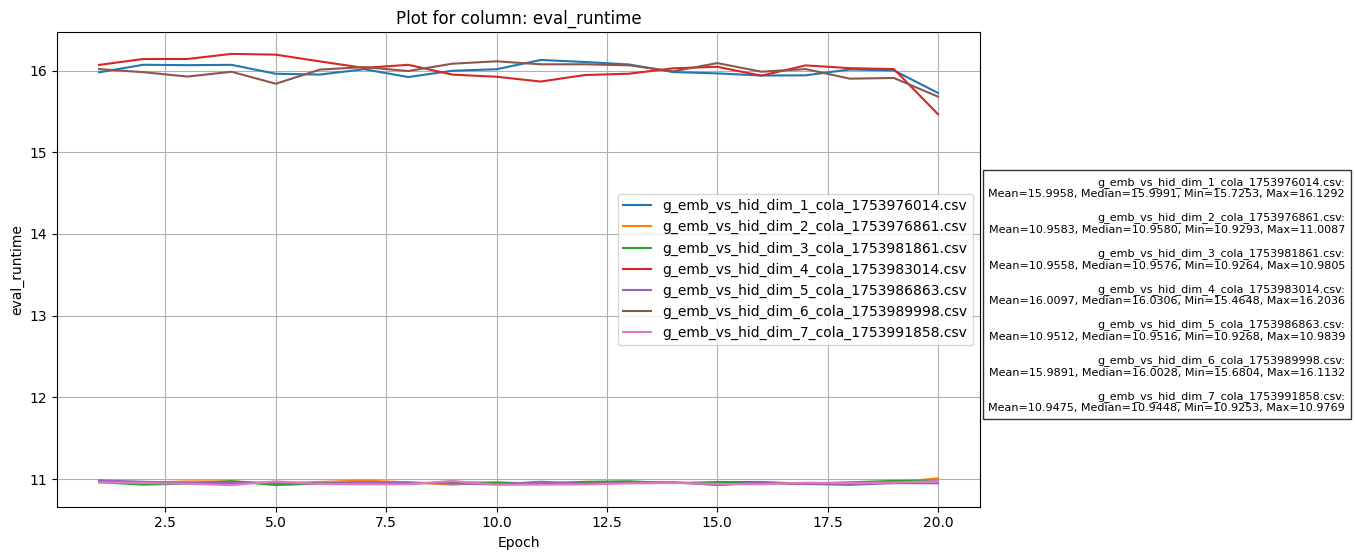

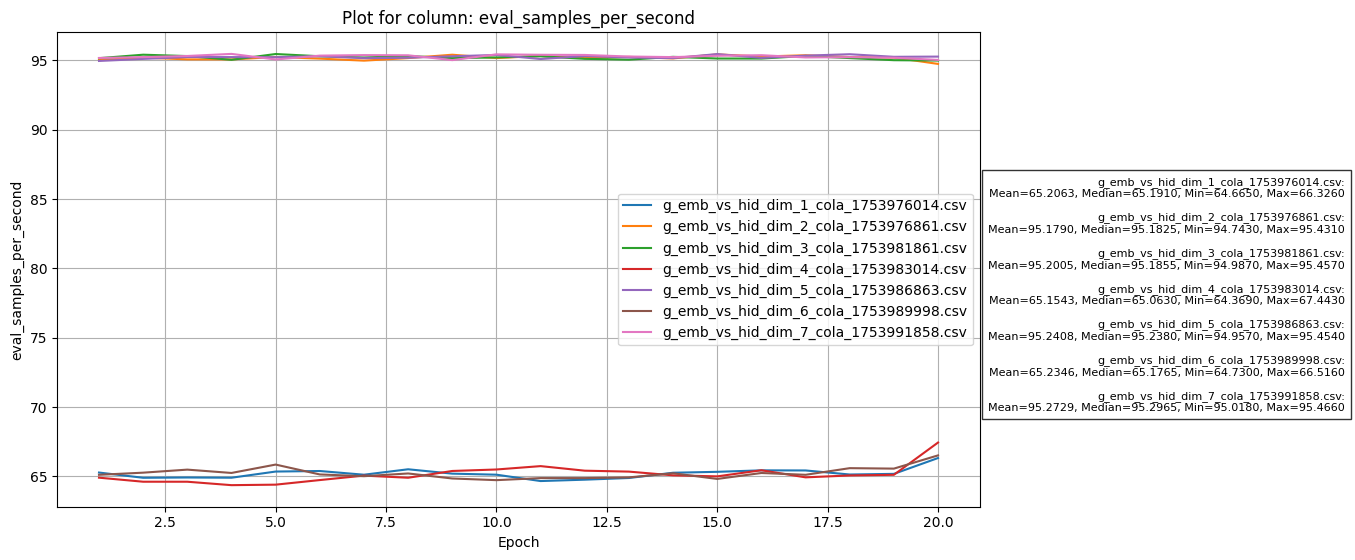

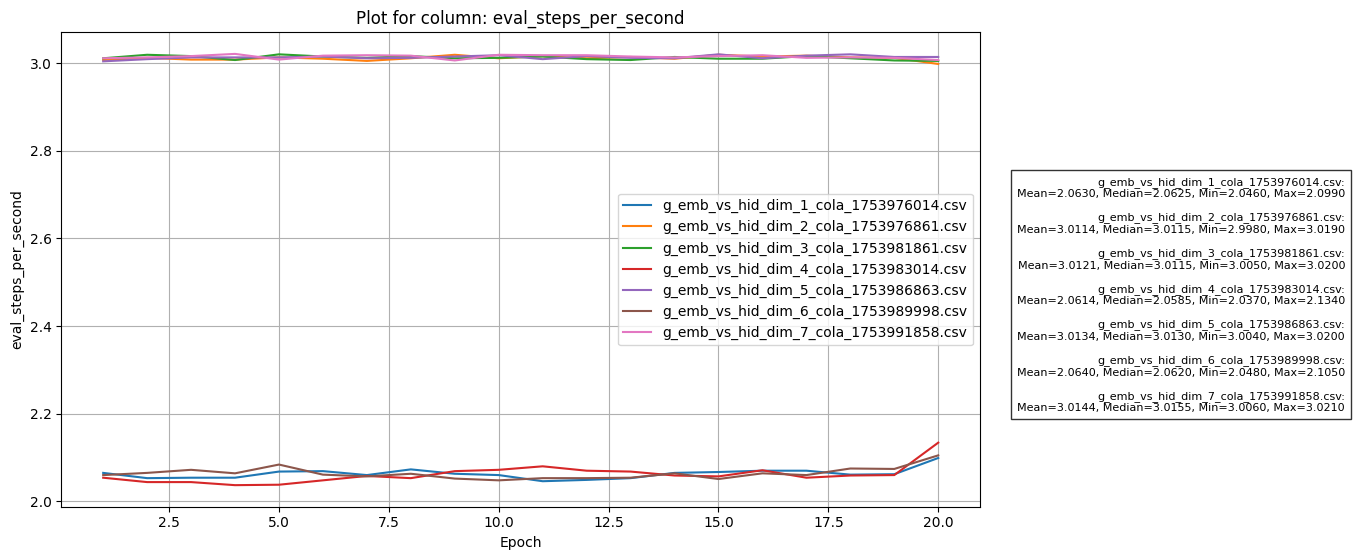

In [7]:
dir_name = "./results/ablation_studies_china/g/"
csv_files = [dir_name + file for file in os.listdir(dir_name)]

plot_csv_columns(csv_files)